---------
Diwali Sales Data Analysis using Python (EDA)
----------

------

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [81]:
df=pd.read_csv('Diwali Sales Data.csv',encoding='unicode_escape')

In [60]:
df.shape

(11239, 13)

In [61]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610858
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355869
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11239 non-null  int64  
 1   Cust_name         11239 non-null  object 
 2   Product_ID        11239 non-null  object 
 3   Gender            11239 non-null  object 
 4   Age Group         11239 non-null  object 
 5   Age               11239 non-null  int64  
 6   Marital_Status    11239 non-null  int64  
 7   State             11239 non-null  object 
 8   Zone              11239 non-null  object 
 9   Occupation        11239 non-null  object 
 10  Product_Category  11239 non-null  object 
 11  Orders            11239 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.2+ MB


Data Cleaning
------

In [8]:
#droping Status as unnamed as it has null values in it
df.drop(['Status','unnamed1'],axis=1,inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


In [11]:
#Checking for null value
pd.isnull(df)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,False,False,False,False,False,False,False,False,False,False,False,False,False
11247,False,False,False,False,False,False,False,False,False,False,False,False,False
11248,False,False,False,False,False,False,False,False,False,False,False,False,False
11249,False,False,False,False,False,False,False,False,False,False,False,False,False


In [13]:
#To check how many null values are there
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [14]:
#Dropping null values as it is not necessary
df.dropna(inplace=True)

In [15]:
pd.isnull(df).sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [65]:
#To remove duplicates
df.drop_duplicates(inplace=True)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11231 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11231 non-null  int64  
 1   Cust_name         11231 non-null  object 
 2   Product_ID        11231 non-null  object 
 3   Gender            11231 non-null  object 
 4   Age Group         11231 non-null  object 
 5   Age               11231 non-null  int64  
 6   Marital_Status    11231 non-null  int64  
 7   State             11231 non-null  object 
 8   Zone              11231 non-null  object 
 9   Occupation        11231 non-null  object 
 10  Product_Category  11231 non-null  object 
 11  Orders            11231 non-null  int64  
 12  Amount            11231 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.2+ MB


In data cleaning step, 
1) Removed irrelevant columns
2) Handled missing values
3) Removed duplicate records
4) Ensured correct data types

In [67]:
#Created age groups to better analyze customer segmentation.
df['Age_Group'] = pd.cut(df['Age'], 
                        bins=[0,18,25,35,50,100],
                        labels=['Teen','Young','Adult','Mid-Age','Senior'])

Exploratory data analysis(EDA)
---------

In [18]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

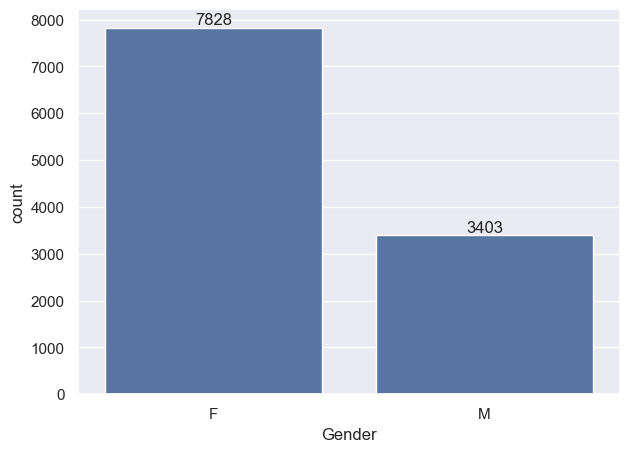

In [75]:
#Count of records based on gender
ax=sns.countplot(x='Gender',data=df)

#to get count in each gender, we make use of containers
for bars in ax.containers:
    ax.bar_label(bars)

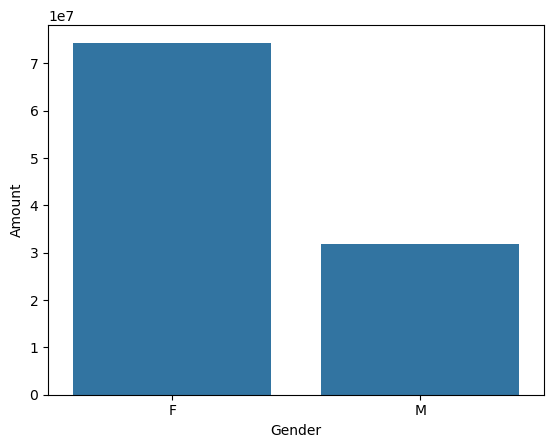

In [23]:
#Grouping genders based on ampount spent
sales_gen=df.groupby(['Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
sns.barplot(x='Gender',y='Amount',data=sales_gen)
plt.show()

Insight:
Female customers contribute more to overall sales during Diwali.

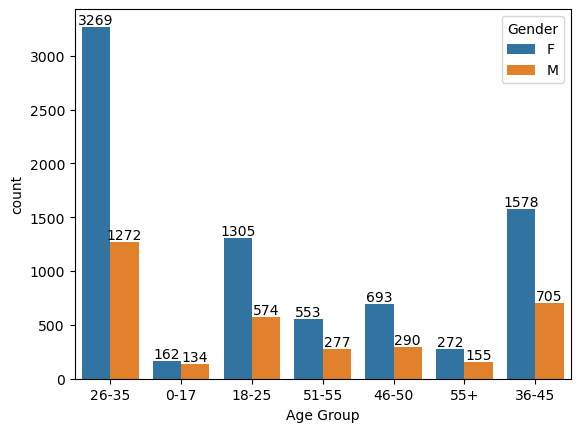

In [27]:
#Grouping based on age group
ax=sns.countplot(data=df,x="Age Group",hue="Gender")
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

Insight:
Female adults (25–35 age group) are the most active buyers.

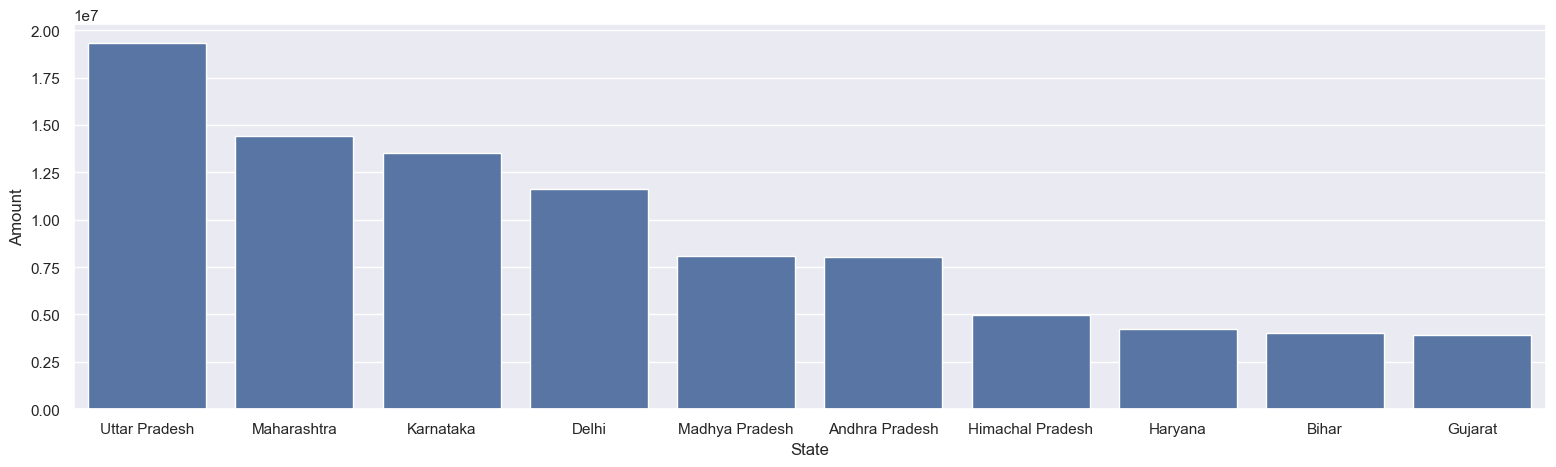

In [77]:
#Top 10 States by Sales
sales_state1=df.groupby(['State'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(10)
sns.set(rc={'figure.figsize':(19,5)})
sns.barplot(data=sales_state1,x='State',y='Amount')
plt.show()

Sales by Marital Status

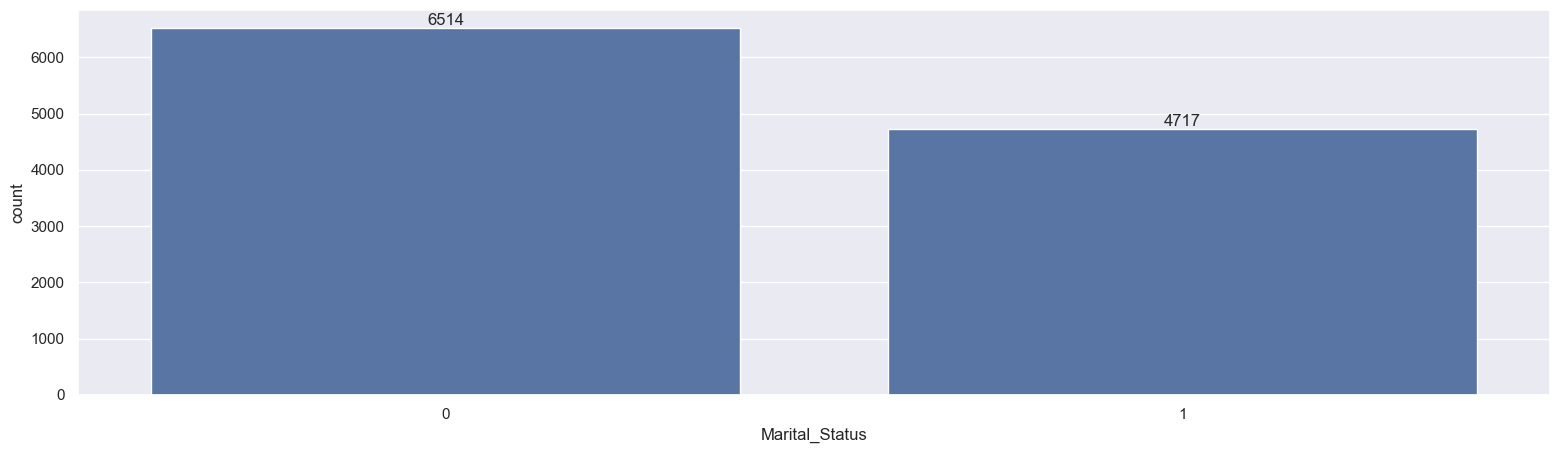

In [79]:
ax=sns.countplot(data=df,x='Marital_Status')
for bars in ax.containers:
    ax.bar_label(bars)  

Sales by Occupation

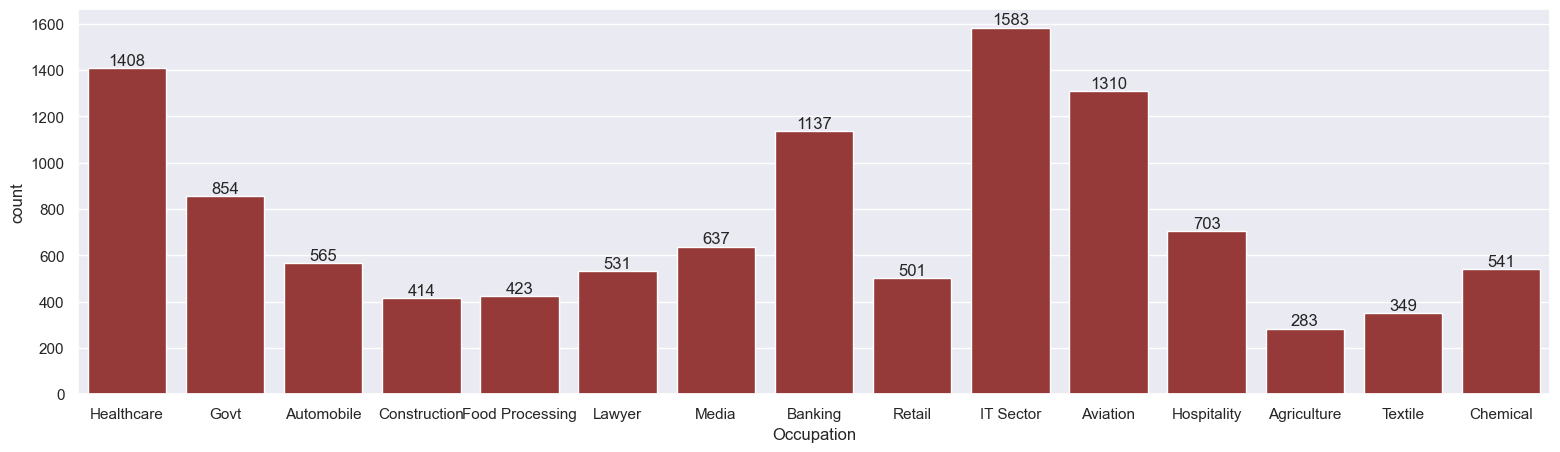

In [52]:
sns.set(rc={'figure.figsize':(19,5)})
ax=sns.countplot(data=df,x='Occupation',color='brown')
for bars in ax.containers:
    ax.bar_label(bars)

Insight:
IT Sector, Healthcase and Aviation professionals are top3 contributors of overall sales.

Product Category Distribution

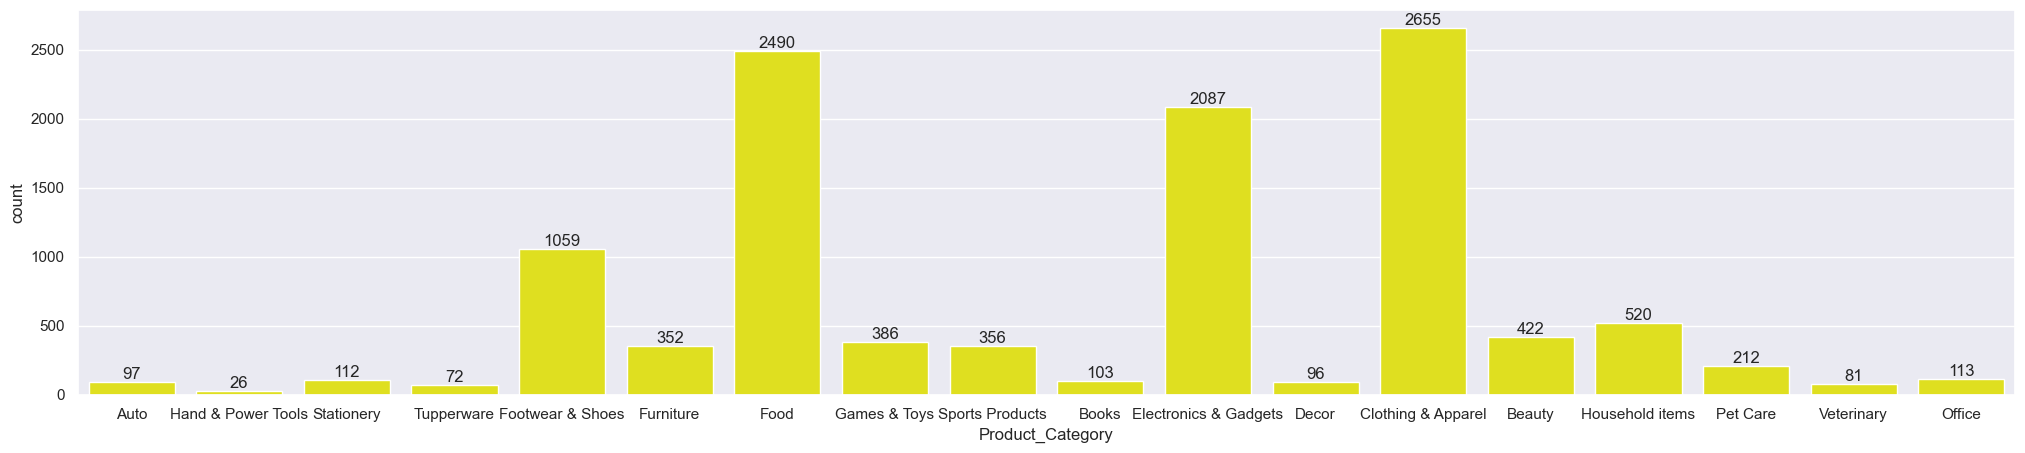

In [58]:
sns.set(rc={'figure.figsize':(25,5)})
ax=sns.countplot(data=df,x='Product_Category',color='yellow')
for bars in ax.containers:
    ax.bar_label(bars)

Insight:
Clothing, Food and Electronics products have more sales during the festive season.

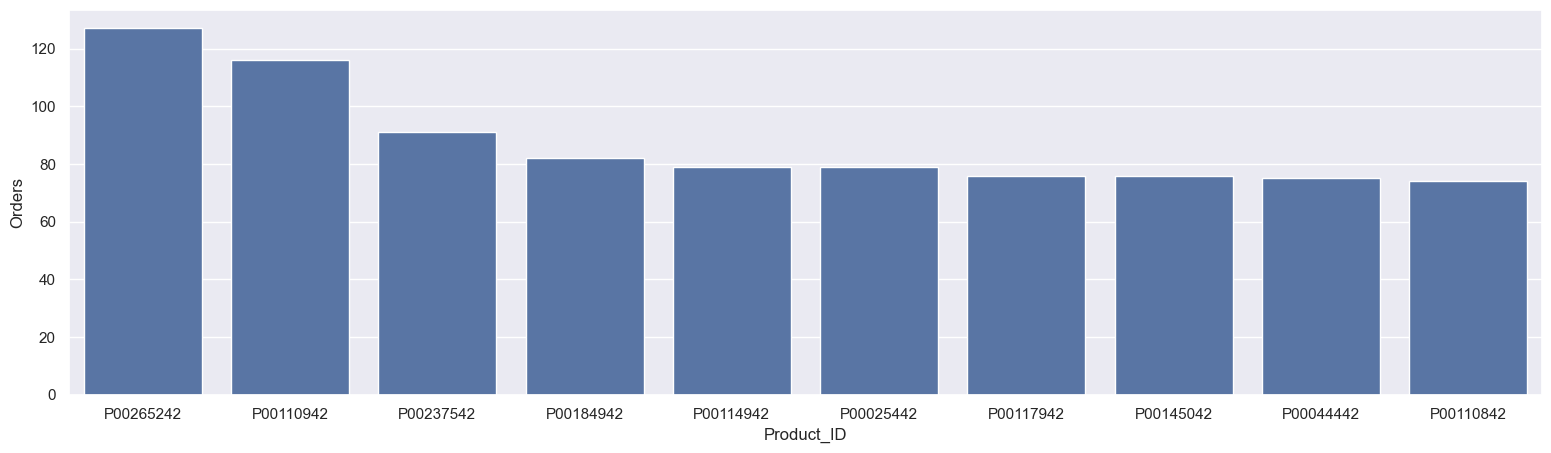

In [57]:
#Top 10 sold products
top_sold=df.groupby(['Product_ID'],as_index=False)['Orders'].sum().sort_values(by='Orders',ascending=False).head(10)
sns.set(rc={'figure.figsize':(19,5)})
sns.barplot(data=top_sold,x='Product_ID',y='Orders')
plt.show()

Sales Distribution

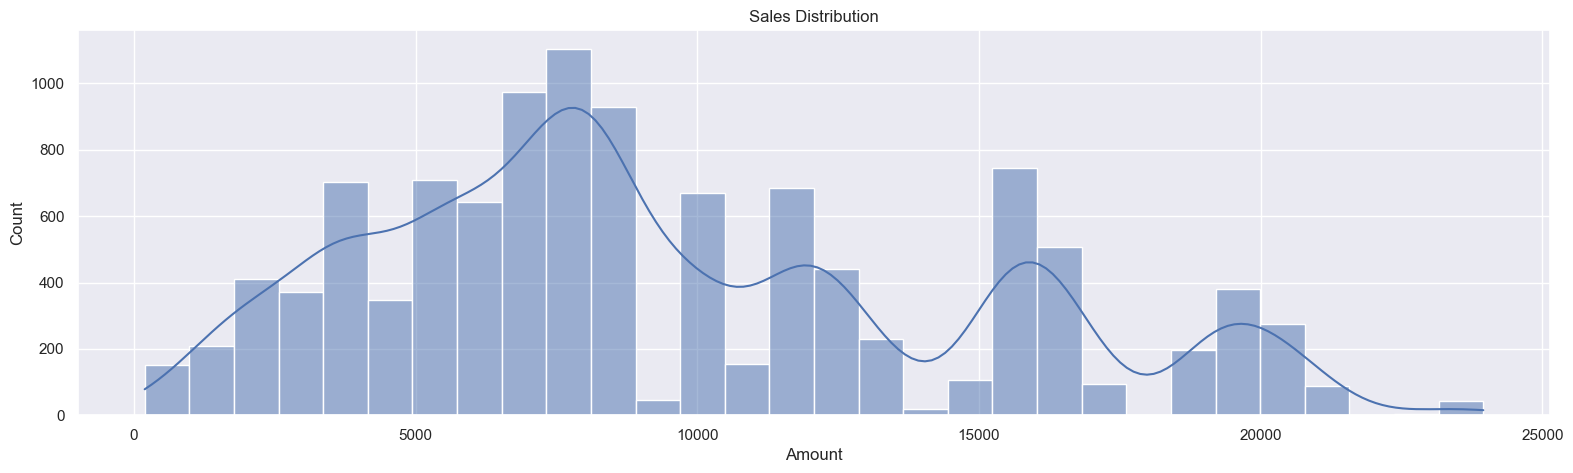

In [82]:
sns.histplot(df['Amount'], bins=30, kde=True)
plt.title("Sales Distribution")
plt.show()

Insight:
Most transactions fall within a specific price range.